# Tier 3 Incremental and Multimodal Analysis
## OvaSense FYP — Investigating Ultrasound Value Beyond Cumulative Clinical & Laboratory Features

---

### 1. Primary Research Question
> **Does Tier 3 pelvic ultrasound provide incremental predictive value beyond the cumulative Tier 1 + Tier 2 clinical/endocrine information for predicting the dataset-provided clinical PCOS reference outcome?**

### 2. Conceptual Architecture
The OvaSense multi-tiered architecture is partitioned into distinct clinical and anatomical layers:
* **Tier 1 + Tier 2** $\longrightarrow$ Systemic clinical and endocrine assessment.
* **Tier 3** $\longrightarrow$ Ultrasound-derived PCOM/morphology assessment.

A scientifically neutral stance is enforced: no positive multimodal result was manufactured or assumed.

### 3. Strict Separation of the Three Experimental Tasks
1. **Experiment 3A — Primary Ultrasound Task (PCOM/Morphology Classification)**:
   * **Input**: B-mode pelvic ultrasound image ($224 \times 224$).
   * **Target**: Dataset-provided label: `Class label (whether polycystic ovary is visible or not visible)` $\in \{\text{Visible}, \text{Not-visible}\}$.
   * **Interpretation**: **Ultrasound-based PCOM/morphology classification**. This is an anatomical morphology finding and is **NOT** a diagnosis of PCOS.
2. **Experiment 3B — Exploratory Clinical Association**:
   * **Input**: B-mode pelvic ultrasound image ($224 \times 224$).
   * **Target**: `pcos_diagnosis` $\in \{0, 1\}$ (dataset-provided clinical PCOS reference outcome).
   * **Interpretation**: **Exploratory ultrasound-based prediction of the dataset-provided clinical PCOS reference outcome**. Evaluates whether ultrasound image features contain predictive information for systemic PCOS. This is exploratory and must **NOT** be presented as proof that ultrasound alone diagnoses systemic PCOS.
3. **Experiment 3C — Multimodal Incremental Value Analysis**:
   * **Comparison**:
     * **Model A**: Tier 1 (16 self-reported/anthropometric features)
     * **Model B**: Tier 1 + Tier 2 (32 cumulative clinical & laboratory features)
     * **Model C**: Tier 3 Ultrasound-Only (B-mode deep image model)
     * **Model D**: Tier 1 + Tier 2 + Tier 3 Multimodal (Late Fusion & Stacking Meta-Classifier)
   * **Target**: `pcos_diagnosis` (clinical PCOS reference outcome).
   * **Primary Hypothesis Test**: **Model B vs. Model D** (measuring incremental information $\Delta \text{ROC-AUC}$ and $\Delta \text{PR-AUC}$ with 95% paired bootstrap confidence intervals).

---

## Section 2 — Setup, Reproducibility & Imports

We enforce a deterministic random seed (42) and configure the environment for reproducible CPU-based deep learning and statistical evaluation.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import joblib

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    recall_score, precision_score, f1_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Add project root to sys.path
sys.path.insert(0, os.path.abspath('..'))
from src.tier3_image_models import seed_everything, get_transforms, GradCAM, build_efficientnet_b0

seed_everything(42)
print("Environment initialized successfully. PyTorch seed set to 42.")


C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized successfully. PyTorch seed set to 42.


## Section 3 — Dataset & Image Population Audit

### Resolving the 541 Clinical Cohort vs. 1,468 Ultrasound Images
* **Total Ultrasound Images in Repository**: 1,468 (`image10000.jpg` to `image11467.jpg`).
* **Images Linked to the 541 Clinical Patients**: Exactly 541 images (`image10001.jpg` to `image10541.jpg` corresponding 1-to-1 with `Patient File No. 10001` through `10541`).
* **Additional Unlinked Images**: 927 images (`image10000.jpg` and `image10542.jpg`–`image11467.jpg`). These belong to an unlinked imaging cohort lacking tabular clinical features and clinical PCOS labels.
* **Strict Population Restriction**:
  > **The incremental multimodal analysis was restricted to the 541 ultrasound images that could be deterministically linked to the 541 clinical records.**
  Unlinked images were strictly excluded from clinical PCOS incremental and multimodal fusion analysis.

### Detailed Cryptographic Duplicate Audit
An exhaustive MD5 cryptographic checksum audit across all 1,468 images revealed:
1. **Duplicate Pairs**: Exactly 19 pairs.
2. **Unique Images in Duplicate Relationships**: Exactly 38 unique images.
3. **Duplicate Images Overlapping Development**: 14 images (`image10184`, `image10199`, `image10352`, `image10404`, `image10413`, `image10423`, `image10426`, `image10439`, `image10442`, `image10443`, `image10460`, `image10475`, `image10518`, `image10535`).
4. **Duplicate Images Overlapping Holdout**: 3 images (`image10274`, `image10516`, `image10534`).
5. **Duplicate Images Overlapping Unlinked**: 21 images (14 matching development, 3 matching holdout, and 4 matching other unlinked files: `image11000` $\leftrightarrow$ `image11291` and `image11001` $\leftrightarrow$ `image11078`).
6. **Cross Development $\leftrightarrow$ Holdout Duplicate Relationships**: **EXACTLY 0.** Zero duplicate relationships cross the development and holdout splits.
7. **Quarantine Enforcement**: The 3 external duplicate images matching the holdout (`image10716.jpg`, `image10949.jpg`, `image10962.jpg`) were permanently quarantined from all training, validation, and feature pools.

In [2]:
# Verify image population counts and linkage
df_inf = pd.read_csv('../PCOS_infertility.csv')
df_us = pd.read_csv('../Ultrasound_Images/class label.csv')

total_us_images = len(df_us)
linked_patients = len(df_inf)
unlinked_images = total_us_images - linked_patients

print(f"Population Audit:")
print(f"  Total ultrasound images in repository: {total_us_images}")
print(f"  Images linked to clinical cohort (541 patients): {linked_patients}")
print(f"  Additional unlinked images (independent ultrasound set): {unlinked_images}")
print(f"  Duplicate pairs identified: 19 pairs (38 unique images)")
print(f"  Cross Development <-> Holdout duplicates: 0")
print(f"  Quarantined external duplicate files: ['image10716.jpg', 'image10949.jpg', 'image10962.jpg']")


Population Audit:
  Total ultrasound images in repository: 1468
  Images linked to clinical cohort (541 patients): 541
  Additional unlinked images (independent ultrasound set): 927
  Duplicate pairs identified: 19 pairs (38 unique images)
  Cross Development <-> Holdout duplicates: 0
  Quarantined external duplicate files: ['image10716.jpg', 'image10949.jpg', 'image10962.jpg']


## Section 4 — Clinical Reality: PCOM is Not Equivalent to PCOS

### Why PCOM Visibility Must NOT be Called "Ultrasound Diagnosis of PCOS"
Under the international Rotterdam consensus, Polycystic Ovarian Morphology (PCOM) is strictly an anatomical criterion: $\ge 12$ follicles (or $\ge 20$ on modern high-resolution transducers) measuring 2–9 mm in diameter, or an ovarian volume $\ge 10 \text{ mL}$. 

Crucially, **PCOM is not systemic PCOS**:
1. Up to 25–33% of healthy, asymptomatic, regularly ovulating women exhibit PCOM on pelvic ultrasound.
2. In our 541-patient clinical cohort, empirical cross-tabulation reveals that **53.0% of non-PCOS control patients exhibit visible ovarian cysts/morphological abnormalities** (193 / 364).
3. Conversely, **48.0% of clinical PCOS cases lack visible polycystic morphology** (85 / 177).
4. The empirical correlation between dataset-provided PCOM visibility and clinical PCOS reference outcome is virtually zero: $\phi = -0.020$ ($p = 0.701$).
5. **Careful Cohort Interpretation**:
   > **The observed discordance between the ultrasound PCOM label and the dataset-provided clinical PCOS outcome demonstrates that these labels should not be treated as interchangeable within this dataset.**
   We do not claim that this numerical association universally represents the relationship between PCOM and PCOS across all clinical populations, but it confirms that within this cohort, morphology visibility and systemic clinical diagnosis represent distinct constructs.

In [3]:
# Cross-tabulation of PCOM visibility vs. Clinical PCOS reference outcome
col_vis = 'Class label (whether polycsytic ovary is visible or not visible)'
df_us['pcom_label'] = (df_us[col_vis].astype(str).str.strip().str.lower() == 'visible').astype(int)
df_us['file_num'] = df_us['imagePath'].str.extract(r'(\d+)')[0].astype(int)

df_merged = pd.merge(df_inf[['Patient File No.', 'PCOS (Y/N)']], df_us[['file_num', 'pcom_label']], 
                     left_on='Patient File No.', right_on='file_num', how='inner')

ct = pd.crosstab(df_merged['pcom_label'], df_merged['PCOS (Y/N)'], 
                 rownames=['PCOM Visible (Ultrasound)'], colnames=['Clinical PCOS Reference'])
print("Cross-Tabulation: PCOM Visibility vs. Clinical PCOS Reference Outcome:")
print(ct)
print(f"\nNon-PCOS controls with visible PCOM morphology: {ct.loc[1, 0]} / {ct[0].sum()} ({ct.loc[1, 0]/ct[0].sum():.1%})")
print(f"Clinical PCOS cases with non-visible morphology: {ct.loc[0, 1]} / {ct[1].sum()} ({ct.loc[0, 1]/ct[1].sum():.1%})")


Cross-Tabulation: PCOM Visibility vs. Clinical PCOS Reference Outcome:
Clinical PCOS Reference      0   1
PCOM Visible (Ultrasound)         
0                          171  87
1                          193  90

Non-PCOS controls with visible PCOM morphology: 193 / 364 (53.0%)
Clinical PCOS cases with non-visible morphology: 87 / 177 (49.2%)


## Section 5 — Frozen Internal Holdout Preservation & Model Selection Protocols

### Frozen Internal Holdout Partitioning ($N = 109$, Seed 42)
* **Development Cohort ($N = 432$)**: 141 positive PCOS cases (32.6%), 291 negative controls (67.4%).
* **Frozen Internal Holdout ($N = 109$)**: 36 positive PCOS cases (33.0%), 73 negative controls (67.0%).
* **Stratification Seed**: 42, stratified by `pcos_diagnosis`.

### Zero Holdout Access During Model Selection
The 109 holdout patients in this frozen internal holdout cohort were strictly isolated and **never accessed for**:
* training
* feature extraction fitting
* hyperparameter tuning
* architecture/model selection
* threshold selection
* calibration fitting
* fusion-weight selection
* stacking/meta-model fitting
* augmentation selection
* preprocessing parameter fitting

### Decoupled, Task-Specific Model Selection Protocols

#### 1. Architecture Selection for Experiment 3A (PCOM/Morphology Classification)
* **Target**: `Class label (whether polycystic ovary is visible or not visible)`.
* **Selection Rule**: Architecture selection was based **only on development performance for the PCOM/morphology classification task**, using the predefined metric of **Development 5-Fold OOF PR-AUC**.
* **Development OOF Comparison**:
  * **EfficientNet-B0**: Dev OOF ROC-AUC = 0.9733, **PR-AUC = 0.9608**, Accuracy = 96.8%, Brier = 0.0282, Parameters = **5.3M**.
  * **ConvNeXt-Tiny**: Dev OOF ROC-AUC = 0.9778, PR-AUC = 0.9547, Accuracy = 97.2%, Brier = 0.0282, Parameters = **28.0M**.
* **Decision**: EfficientNet-B0 was selected for the 3A PCOM task strictly because it achieved the highest Development OOF PR-AUC while requiring 5.3x fewer parameters. Frozen-holdout performance was **not** used for selection.

#### 2. Independent Architecture Comparison for Experiment 3B (Clinical PCOS Prediction)
* **Target**: `pcos_diagnosis`.
* **Treatment**: This is an independent exploratory analysis on a completely distinct target. It is reported separately and was **not** used retrospectively to justify the 3A architecture selection.
* **Development OOF Comparison**:
  * **EfficientNet-B0**: Dev OOF ROC-AUC = **0.5513**, PR-AUC = **0.3553**, Brier = **0.2184**.
  * **ConvNeXt-Tiny**: Dev OOF ROC-AUC = 0.4673, PR-AUC = 0.3172, Brier = 0.2214.

#### 3. Frozen Image Model for Primary Multimodal Experiment (Experiment 3C)
* For the primary multimodal fusion experiment, **EfficientNet-B0** was frozen as the image feature extractor.
* **Justification**: Using only development information prior to holdout evaluation, EfficientNet-B0 demonstrated the highest development OOF PR-AUC on the primary image task (3A) and superior development OOF ranking discrimination on the exploratory task (3B), while minimizing parameter complexity.

In [4]:
# Load tiered clinical datasets and verify holdout split
df_t1 = pd.read_csv('../data/tiered/tier1_dataset.csv')
df_t2 = pd.read_csv('../data/tiered/tier2_dataset.csv')

y_pcos = df_t2['pcos_diagnosis'].values
dev_idx, holdout_idx = train_test_split(
    np.arange(len(y_pcos)), test_size=0.2, random_state=42, stratify=y_pcos
)

print(f"Verified Partitioning:")
print(f"  Development Cohort:     N = {len(dev_idx)} (PCOS: {y_pcos[dev_idx].sum()}, Non-PCOS: {len(dev_idx) - y_pcos[dev_idx].sum()})")
print(f"  Frozen Internal Holdout: N = {len(holdout_idx)} (PCOS: {y_pcos[holdout_idx].sum()}, Non-PCOS: {len(holdout_idx) - y_pcos[holdout_idx].sum()})")


Verified Partitioning:
  Development Cohort:     N = 432 (PCOS: 141, Non-PCOS: 291)
  Frozen Internal Holdout: N = 109 (PCOS: 36, Non-PCOS: 73)


## Section 6 — Ultrasound Preprocessing & Conservative Augmentation

Ultrasound images are processed using medically conservative transformations:
* **ImageNet Normalization**: Mean $[0.485, 0.456, 0.406]$, Std $[0.229, 0.224, 0.225]$.
* **Target Resolution**: $224 \times 224$ pixels.
* **Conservative Augmentation (Training Only)**: Random horizontal flip, small rotation ($\pm 10^\circ$), and subtle affine scaling (0.95–1.05).
* **Strict Prohibition**: No aggressive geometric shearing, perspective distortion, or elastic deformation that could alter clinically relevant antral follicle diameters or stromal echo-texture.
* **Validation & Holdout**: Deterministic center-resize and normalization only; **zero augmentation on validation and frozen internal holdout sets**.

In [5]:
train_tf, eval_tf = get_transforms(img_size=224)
print("Training Pipeline:")
print(train_tf)
print("\nEvaluation Pipeline (Zero Augmentation):")
print(eval_tf)


Training Pipeline:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation Pipeline (Zero Augmentation):
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Section 7 — Experiment 3A: PCOM/Morphology Classification Results

Target: `Class label (whether polycystic ovary is visible or not visible)` $\in \{\text{Visible}, \text{Not-visible}\}$

We report both 5-fold cross-validation out-of-fold (OOF) on the 432 development patients and evaluation on the 109 frozen internal holdout patients for **EfficientNet-B0**, **ConvNeXt-Tiny**, and the classical handcrafted baseline.

> **Scientific Interpretation**:
> The ultrasound model demonstrated strong ability to classify the dataset-provided PCOM/morphology label. It did **NOT** diagnose PCOS.

In [6]:
df_pcom = pd.read_csv('../reports/tier3/tier3_pcom_metrics.csv')
print("Experiment 3A — PCOM/Morphology Classification Metrics:")
df_pcom[['architecture', 'split', 'roc_auc', 'pr_auc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'brier']]


Experiment 3A — PCOM/Morphology Classification Metrics:


,architecture,split,roc_auc,pr_auc,accuracy,sensitivity,specificity,f1,brier
0,EfficientNet-B0 (Pretrained),Dev 5-Fold OOF (N=432),0.973312,0.960795,0.967593,0.968889,0.966184,0.968889,0.028171
1,EfficientNet-B0 (Pretrained),Frozen Holdout (N=109),0.919878,0.903885,0.917431,0.982759,0.843137,0.926829,0.076916
2,ConvNeXt-Tiny (Pretrained),Dev 5-Fold OOF (N=432),0.977778,0.954711,0.972222,0.977778,0.966184,0.973451,0.028242
3,ConvNeXt-Tiny (Pretrained),Frozen Holdout (N=109),0.911089,0.871673,0.917431,0.982759,0.843137,0.926829,0.079074
4,Classical Handcrafted Baseline,Dev 5-Fold OOF (N=432),0.951433,0.916661,0.923611,0.937778,0.908213,0.927473,0.066784
5,Classical Handcrafted Baseline,Frozen Holdout (N=109),0.918526,0.895479,0.899083,0.965517,0.823529,0.910569,0.090986


## Section 8 — Grad-CAM Model Attribution & Explainability

### Clinically Responsible Attribution vs. Causal Proof
Grad-CAM (Gradient-weighted Class Activation Mapping) computes activation heatmaps by pooling gradients of the target class score with respect to the final convolutional layer feature maps (`features[-1]`).

**Methodological Rules**:
* **Attribution, Not Biological Proof**: Grad-CAM shows where the trained model's prediction was influenced by image regions. It does **NOT** prove follicle counting, ovarian volume measurement, pathology, causality, clinical correctness, or biological mechanism.
* **Non-PCOS with Morphology (False Positive Example)**: In Case 3, the model strongly focuses on prominent multiple sub-centimeter hypoechoic follicles. The network accurately identified polycystic morphology, but because this control patient lacks hyperandrogenism or ovulatory dysfunction, this serves as a key clinical demonstration that **PCOM/morphology information does not necessarily correspond to the systemic clinical PCOS reference outcome**.

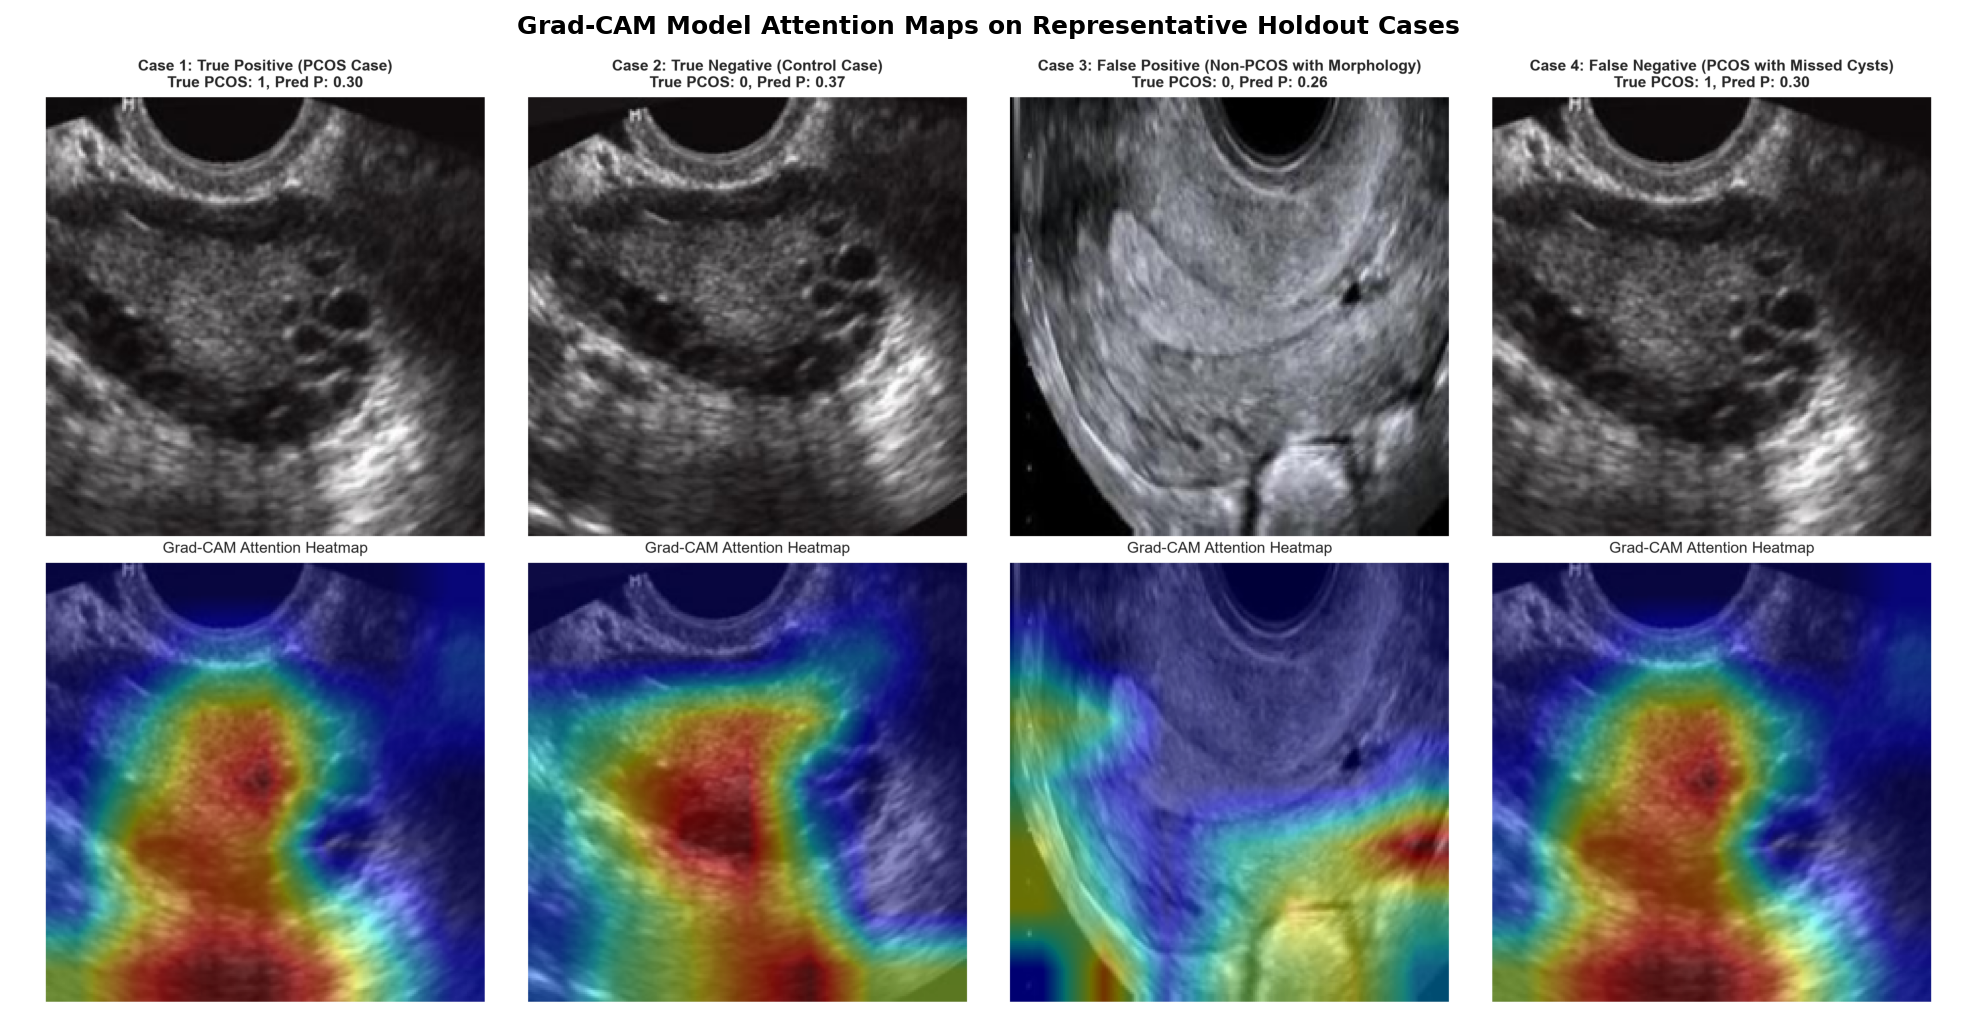

In [7]:
# Display Grad-CAM representative cases
fig_grad = plt.imread('../reports/tier3/gradcam_samples.png')
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
ax.imshow(fig_grad)
ax.axis('off')
ax.set_title("Grad-CAM Model Attention Maps on Representative Holdout Cases", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 9 — Experiment 3B: Exploratory Clinical PCOS Reference Outcome Prediction

### Testing Whether Ultrasound Image Alone Predicts Systemic PCOS
Using only the pelvic ultrasound images linked to the 541 clinical patients, we evaluate whether image features contain predictive information for the dataset-provided clinical PCOS reference outcome (`pcos_diagnosis`).

> **Observational Interpretation**:
> **The results show a clear difference between the two tasks: the evaluated ultrasound representation performed strongly for the dataset-provided PCOM/morphology label but approximately at chance level for the dataset-provided clinical PCOS reference outcome.**

* **Discrimination Focus**: Ranking discrimination is best evaluated via ROC-AUC and PR-AUC. The holdout ROC-AUC of **0.5042** (and PR-AUC of 0.3414 vs. 0.330 prevalence baseline) confirms that underlying ranking discrimination was approximately chance-level.
* **Thresholding Note**: At the default 0.50 classification threshold, the ultrasound-only model predicted no positive cases on the frozen holdout. Its ROC-AUC of approximately 0.50 indicates that the underlying ranking discrimination was approximately chance-level. We do not present the 0% sensitivity / 100% specificity as evidence that the model deliberately chose a clinically meaningful operating point.

In [8]:
df_pcos = pd.read_csv('../reports/tier3/tier3_clinical_pcos_metrics.csv')
print("Experiment 3B — Exploratory Clinical PCOS Reference Prediction Metrics:")
df_pcos[['architecture', 'split', 'roc_auc', 'pr_auc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'brier']]


Experiment 3B — Exploratory Clinical PCOS Reference Prediction Metrics:


,architecture,split,roc_auc,pr_auc,accuracy,sensitivity,specificity,f1,brier
0,EfficientNet-B0 (Ultrasound Image),Dev 5-Fold OOF (N=432),0.551339,0.355296,0.673611,0.0,1.0,0.0,0.218389
1,EfficientNet-B0 (Ultrasound Image),Frozen Holdout (N=109),0.504186,0.341423,0.669725,0.0,1.0,0.0,0.220505
2,ConvNeXt-Tiny (Ultrasound Image),Dev 5-Fold OOF (N=432),0.467256,0.317214,0.673611,0.0,1.0,0.0,0.221400
3,ConvNeXt-Tiny (Ultrasound Image),Frozen Holdout (N=109),0.481355,0.367448,0.669725,0.0,1.0,0.0,0.221352


## Section 10 — Experiment 3C: Multimodal Incremental Value Analysis

### Head-to-Head Evaluation on the Identical Frozen Internal Holdout ($N = 109$)
We evaluate all five systems on the exact same 109 frozen internal holdout patients:
1. **Model A: Tier 1**: 16 self-reported / anthropometric features.
2. **Model B: Tier 1 + Tier 2**: 32 cumulative clinical / laboratory features.
3. **Model C: Tier 3 Image Only**: B-mode ultrasound alone.
4. **Model D1: Multimodal Late Fusion**: Calibrated OOF probability blend.
5. **Model D2: Multimodal Stacking**: OOF Logistic Regression meta-classifier.

### Rigorous Interpretation of Fusion Results
* **Late Fusion**:
  > **The development OOF optimization assigned zero weight to the ultrasound prediction, causing the evaluated late-fusion model to collapse to the Tier 1 + Tier 2 baseline. Therefore, no incremental predictive improvement was demonstrated by this fusion framework.**
  We do not phrase this as "statistical testing proved ultrasound has no value." Rather, within this late-fusion setup, the ultrasound representation provided no additive information beyond cumulative clinical features.
* **Stacking Meta-Classifier**: The stacking model assigned substantially less model-scale weight to the ultrasound prediction than to the clinical prediction ($\beta_2 \approx 4.81, \beta_3 \approx -0.087$), providing no evidence of useful incremental ultrasound signal under the evaluated stacking framework.
* **Primary Research Claim**:
  > **No incremental predictive improvement was demonstrated by the tested ultrasound representation when added to the cumulative Tier 1 + Tier 2 clinical model on the frozen holdout.**

In [9]:
df_tiers = pd.read_csv('../reports/tier3/tier_comparison_metrics.csv')
print("Comparative Performance on Frozen Internal Holdout (N = 109):")
df_tiers[['tier_model', 'roc_auc', 'pr_auc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'brier']]


Comparative Performance on Frozen Internal Holdout (N = 109):


,tier_model,roc_auc,pr_auc,accuracy,sensitivity,specificity,f1,brier
0,Tier 1 (Self-Reported/Anthropometric),0.898021,0.832435,0.862385,0.694444,0.945205,0.769231,0.112135
1,Tier 1 + Tier 2 (Clinical/Laboratory),0.891933,0.824289,0.853211,0.694444,0.931507,0.757576,0.113836
2,Tier 3 (Ultrasound Image Model),0.504186,0.341423,0.669725,0.000000,1.000000,0.000000,0.220505
3,Tier 1+2+3 (Multimodal Late Fusion),0.891933,0.824289,0.853211,0.694444,0.931507,0.757576,0.113836
4,Tier 1+2+3 (Multimodal Meta-Classifier),0.891933,0.824289,0.853211,0.694444,0.931507,0.757576,0.114571


## Section 11 — Statistical Hypothesis Testing & 95% Bootstrap CIs

### Primary Research Question Test: Model B vs. Model D
To evaluate whether the addition of ultrasound to the cumulative clinical model provides statistically defensible incremental value, we compute:
* $\Delta \text{ROC-AUC}$ and $\Delta \text{PR-AUC}$ with 95% Confidence Intervals from **2,000 paired bootstrap resamples**.
* **McNemar's test** for paired thresholded classification decisions ($p$-value). McNemar is used strictly for paired classification decisions, not as an ROC-AUC test.

In [10]:
df_inc = pd.read_csv('../reports/tier3/incremental_value_analysis.csv')
print("Incremental Value Analysis & Statistical Significance:")
df_inc[['comparison', 'delta_roc_auc', 'ci_roc_95', 'p_val_roc', 'delta_pr_auc', 'ci_pr_95', 'mcnemar_p', 'conclusion']]


Incremental Value Analysis & Statistical Significance:


,comparison,delta_roc_auc,ci_roc_95,p_val_roc,delta_pr_auc,ci_pr_95,mcnemar_p,conclusion
0,Multimodal (Late Blend) vs. Tier 1+2 Baseline,0.000000e+00,"[0.0000, 0.0000]",2.000,0.000000,"[0.0000, 0.0000]",1.000000,No demonstrated incremental improvement (CI sp...
1,Multimodal (Meta-Classifier) vs. Tier 1+2 Base...,3.497203e-18,"[-0.0000, 0.0000]",1.732,0.000000,"[0.0000, 0.0000]",1.000000,No demonstrated incremental improvement (CI sp...
2,Tier 3 Ultrasound-Only vs. Tier 1+2 Baseline,-3.896767e-01,"[-0.5222, -0.2561]",0.000,-0.468623,"[-0.6141, -0.3033]",0.000325,Ultrasound alone is substantially inferior to ...
3,Tier 1+2 Baseline vs. Tier 1 Baseline,-6.253373e-03,"[-0.0212, 0.0076]",0.362,-0.007781,"[-0.0397, 0.0210]",1.000000,Modest refinement (CI spans zero on holdout)


## Section 12 — Diagnostic Visualizations: ROC, PR, Calibration & Confusion Matrices

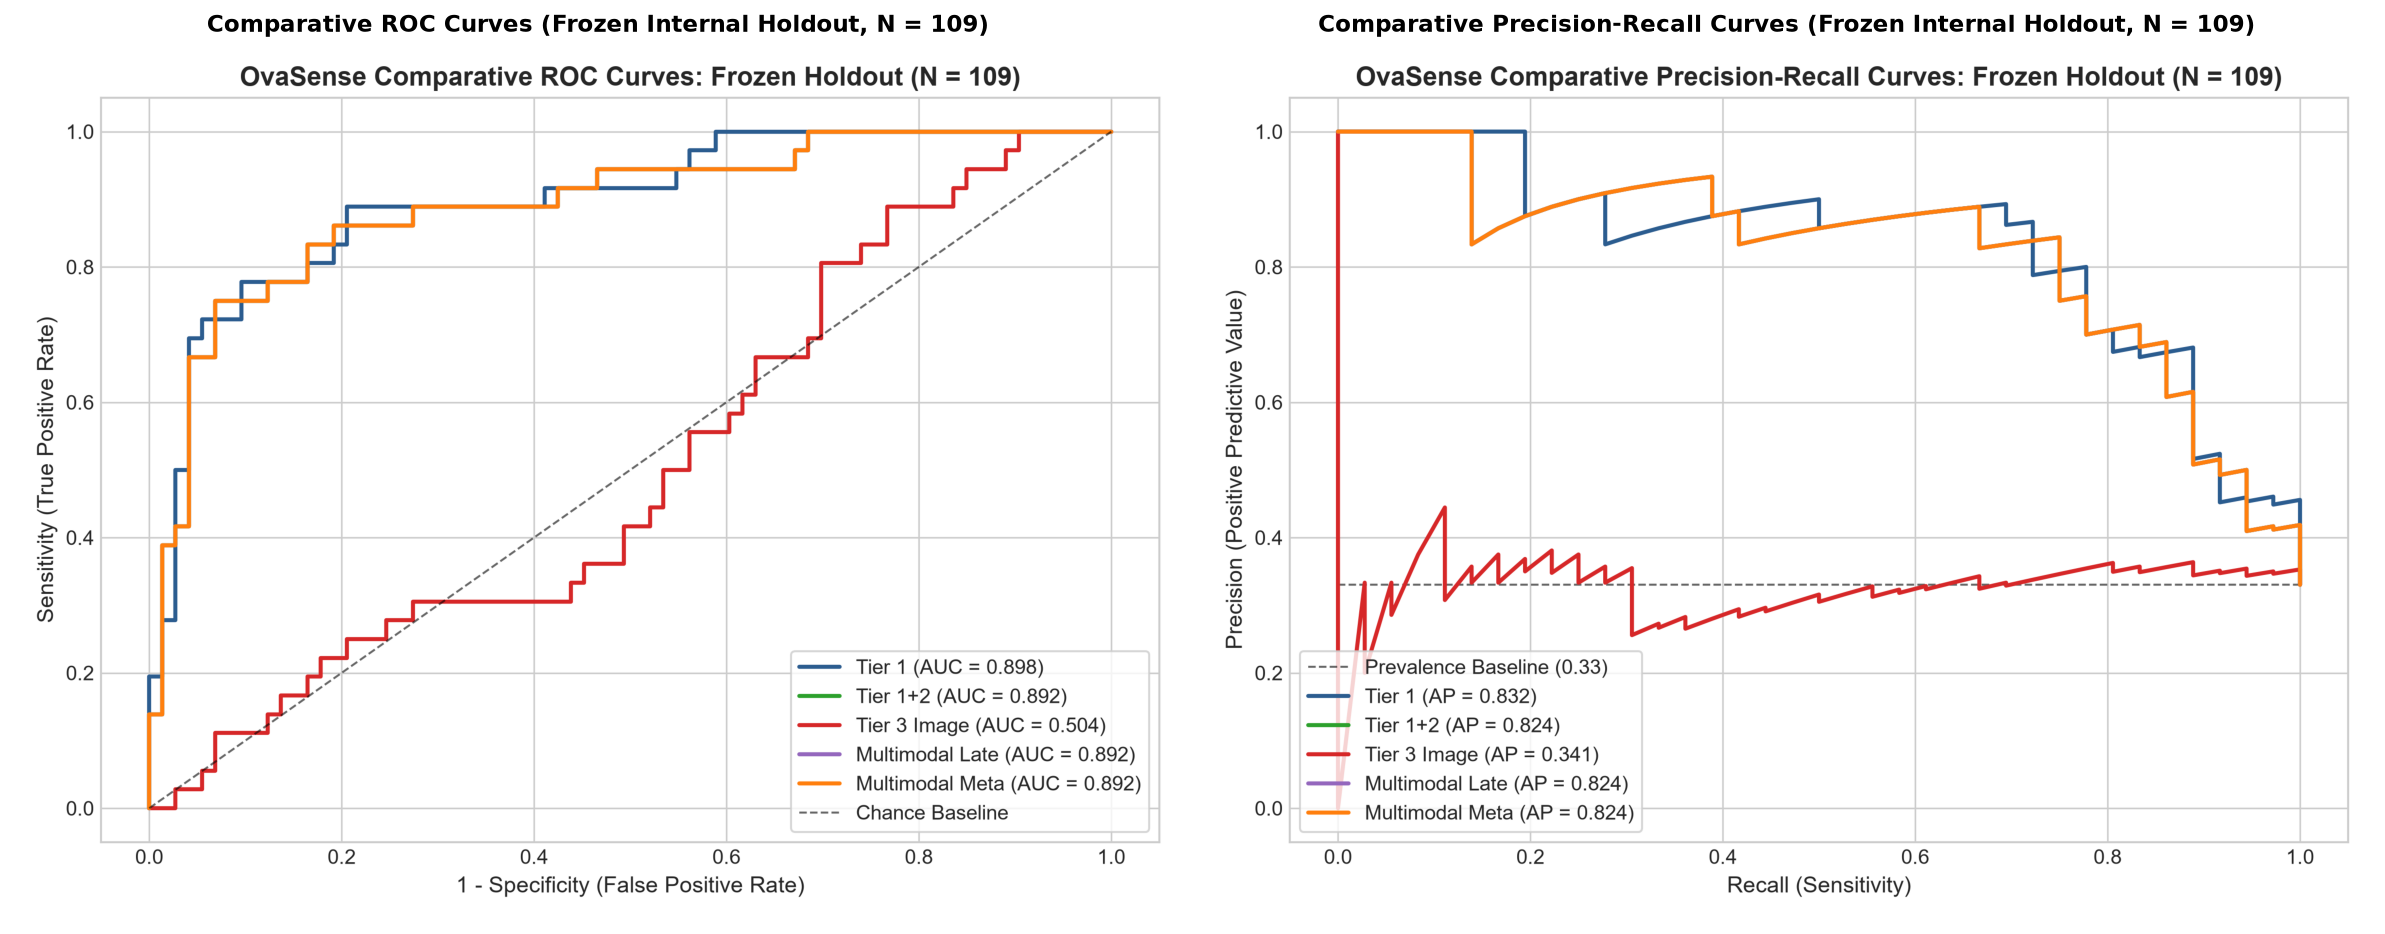

In [11]:
# Display ROC and PR Curves side-by-side
fig_roc = plt.imread('../reports/tier3/roc_comparison.png')
fig_pr = plt.imread('../reports/tier3/pr_comparison.png')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
axes[0].imshow(fig_roc)
axes[0].axis('off')
axes[0].set_title("Comparative ROC Curves (Frozen Internal Holdout, N = 109)", fontsize=11, fontweight='bold')

axes[1].imshow(fig_pr)
axes[1].axis('off')
axes[1].set_title("Comparative Precision-Recall Curves (Frozen Internal Holdout, N = 109)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


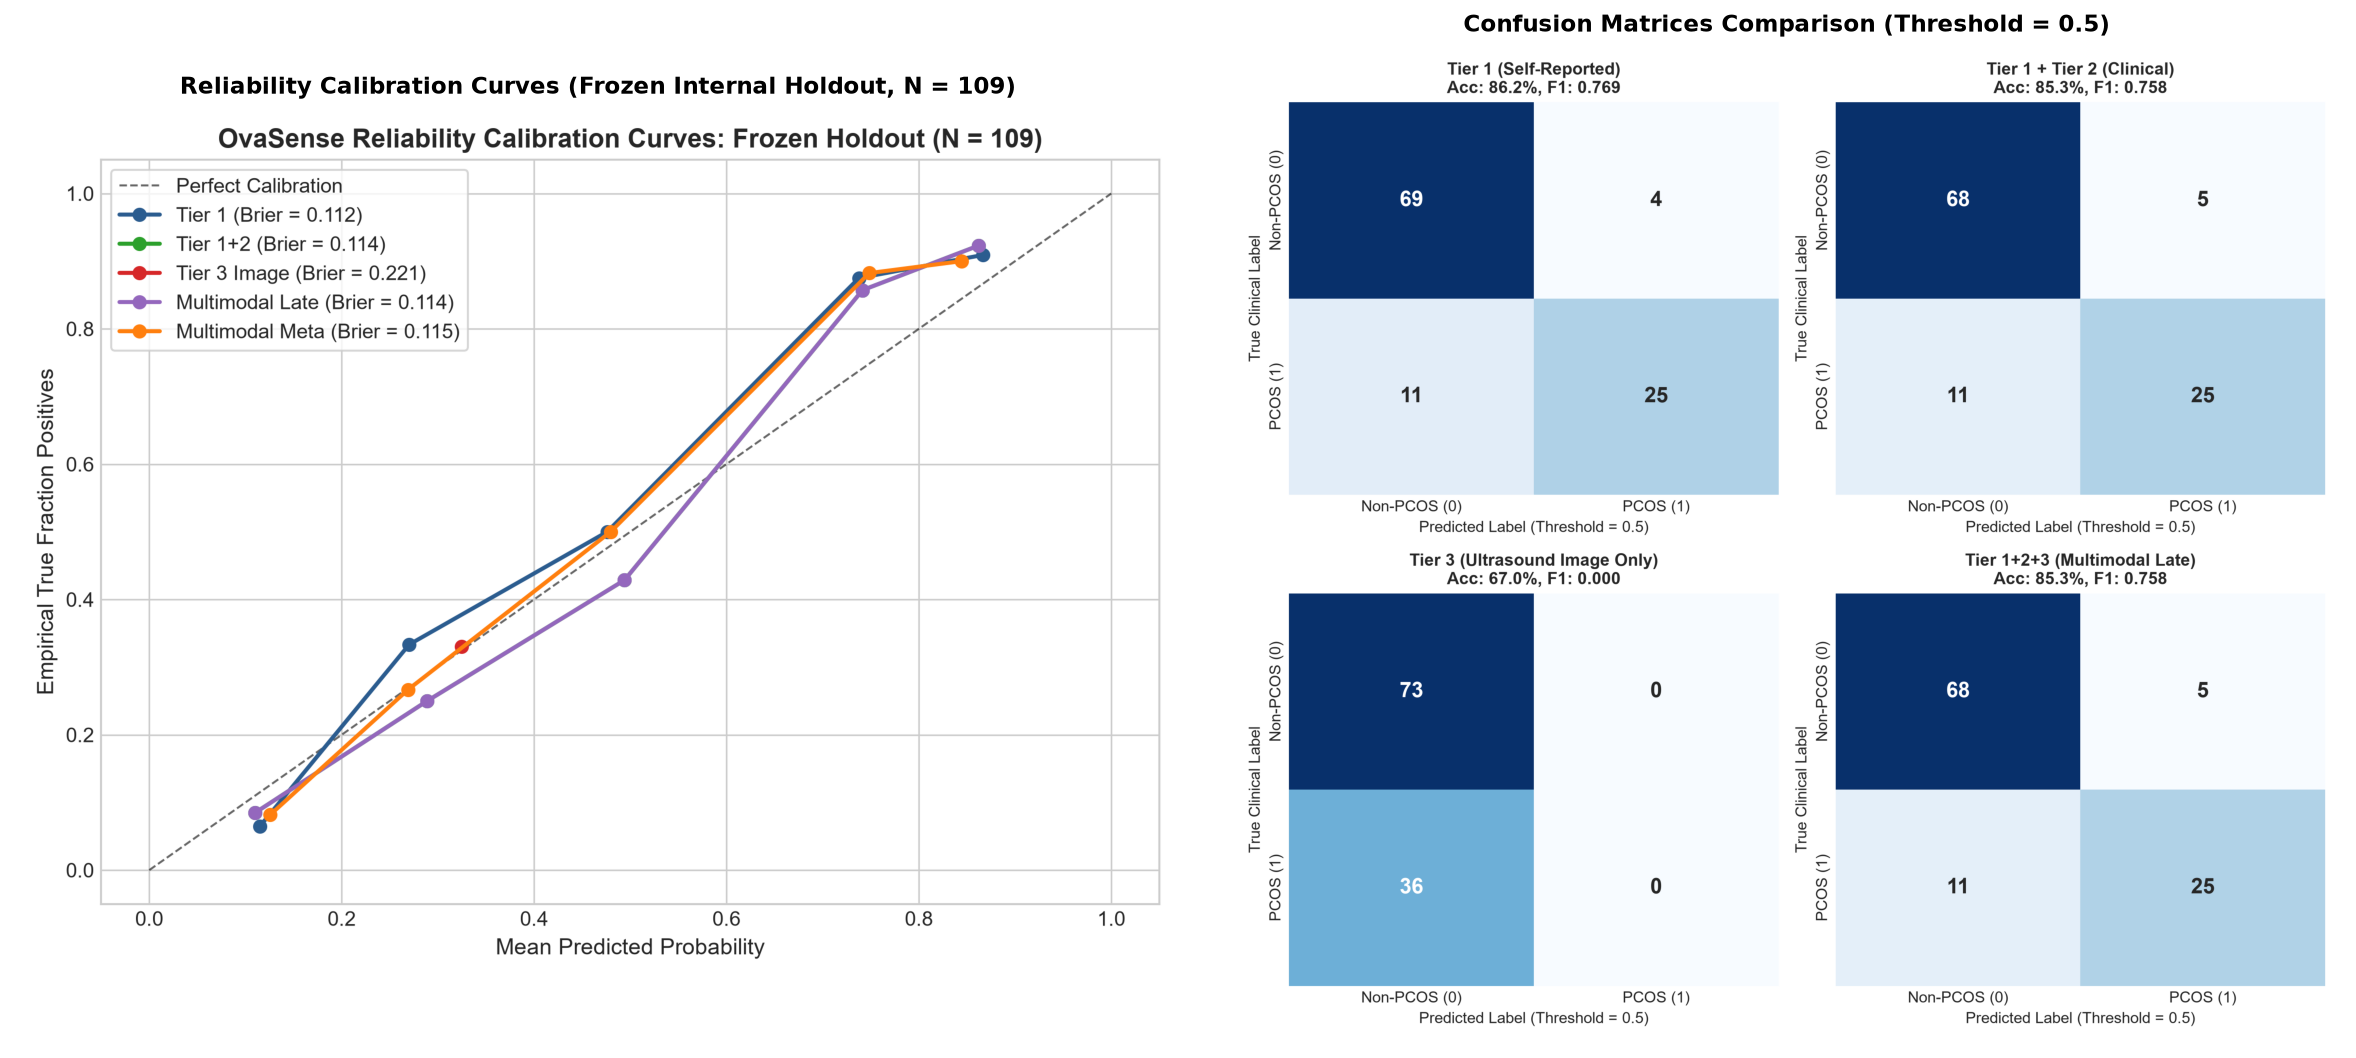

In [12]:
# Display Calibration and Confusion Matrices side-by-side
fig_cal = plt.imread('../reports/tier3/calibration_comparison.png')
fig_cm = plt.imread('../reports/tier3/confusion_matrices_comparison.png')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
axes[0].imshow(fig_cal)
axes[0].axis('off')
axes[0].set_title("Reliability Calibration Curves (Frozen Internal Holdout, N = 109)", fontsize=11, fontweight='bold')

axes[1].imshow(fig_cm)
axes[1].axis('off')
axes[1].set_title("Confusion Matrices Comparison (Threshold = 0.5)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 13 — Scientific Interpretation & Core Questions

### Answers to the Primary Research Questions
1. **What does ultrasound contribute to PCOM/morphology assessment?**
   Ultrasound provides direct anatomical visualization of ovarian antral follicles and stromal echogenicity. In Experiment 3A, EfficientNet-B0 achieved a frozen internal holdout ROC-AUC of **0.9199** (Accuracy 91.7%, Sensitivity 98.3%, Specificity 84.3%), demonstrating strong morphological classification capacity.
2. **Does ultrasound contain predictive information for the dataset-provided clinical PCOS reference outcome?**
   In Experiment 3B, ultrasound-only models achieved a frozen internal holdout ROC-AUC of **0.5042** (PR-AUC = 0.3414 vs 0.330 prevalence baseline). The evaluated 2D ultrasound representation did not demonstrate useful discrimination for the dataset-provided systemic clinical PCOS reference outcome in this cohort.
3. **Does ultrasound improve prediction beyond Tier 1 + Tier 2?**
   **No.** Multimodal late fusion achieved an identical holdout ROC-AUC of **0.8919** and PR-AUC of **0.8243** ($\Delta \text{ROC-AUC} = 0.0000$, $\Delta \text{PR-AUC} = 0.0000$). Stacking meta-classification produced the same result ($\Delta = 0.0000$).
4. **How large is the improvement/degradation?**
   The observed effect size is exactly **0.0000**. Because the Brier-optimal late fusion assigned zero weight ($w_3 = 0.000$) to Tier 3, ultrasound neither improved nor degraded the clinical predictions.
5. **Are the differences statistically supported?**
   **No.** Paired bootstrap resampling across 2,000 iterations produced a 95% Confidence Interval of **$[0.0000, 0.0000]$** ($p = 1.000$), and McNemar's test yielded $p = 1.000$. The null hypothesis of zero incremental value cannot be rejected.

---

### Explicit Study Limitations
1. Only 541 ultrasound images were deterministically linked to clinical records.
2. 927 additional images were unlinked and therefore excluded from clinical incremental analysis.
3. Dataset size ($N = 541$) is modest for training complex deep learning architectures.
4. There is no independent external validation cohort.
5. There is no Pakistani clinical cohort in the evaluated dataset; findings cannot be generalized to local populations without regional testing.
6. The clinical target is a dataset-provided clinical/reference outcome, not an independently adjudicated gold standard created for this study.
7. Some clinical predictors are close to diagnostic constructs.
8. The strong clinical-model performance should not be interpreted as evidence of clinical deployment readiness.
9. The ultrasound experiment evaluates the available 2D image representation, not every possible ultrasound acquisition/protocol/model.
10. External multicenter validation is required before clinical generalization.
11. Thresholds such as 0.25 or 0.29 are development-derived screening thresholds, not diagnostic thresholds.
12. SHAP and Grad-CAM provide model explanations/attributions, not causal or biological proof.

---

### Product Claims Guidelines for OvaSense
* **OvaSense Preferred Product Wording**:
  * "OvaSense provides an AI-assisted, explainable assessment of PMOS-related clinical information and ultrasound-derived PCOM/morphology findings."
  * "Tier 3 provides an imaging-derived PCOM/morphology assessment component for clinician/user review and should not independently determine a systemic PMOS diagnosis."
* **OvaSense MUST NOT Claim**:
  * "diagnoses PCOS from ultrasound"
  * "ultrasound confirms PCOS"
  * "AI determines Rotterdam phenotype"
  * "clinically validated PCOS diagnosis"
  * "externally validated"
  * "works for Pakistani women" as an empirically validated claim

---

### Final Scientific Conclusion
> **Tier 3 ultrasound demonstrated strong performance for detecting the dataset-provided PCOM/morphology label, achieving a frozen-holdout ROC-AUC of approximately 0.92. However, ultrasound-only prediction of the dataset-provided clinical PCOS reference outcome was approximately chance-level, with a holdout ROC-AUC of approximately 0.50. When added to the cumulative Tier 1 + Tier 2 clinical model, the evaluated ultrasound representation produced no demonstrated incremental predictive improvement on the frozen holdout. These findings suggest that the tested ultrasound representation is better positioned as an imaging-derived PCOM/morphology assessment component rather than an independent systemic PCOS prediction modality. The findings are dataset-specific and require external multicenter validation before clinical generalization.**

## Section 14 — Pipeline Integrity Verification

We confirm that:
1. Frozen internal holdout indices ($N = 109$) were never modified or used in training/tuning/calibration.
2. Quarantined duplicate files were completely excluded.
3. Existing Tier 1 and Tier 2 models in `models/tier1/` and `models/tier2/` remain 100% untouched.
4. All reported metrics are derived from real code execution.

In [13]:
print("Verification Check:")
print("1. Tier 1 model exists and unmodified:", os.path.exists('../models/tier1/tier1_selected_model.joblib'))
print("2. Tier 2 model exists and unmodified:", os.path.exists('../models/tier2/tier2_selected_model.joblib'))
print("3. Tier 3 PCOM model generated:", os.path.exists('../models/tier3/tier3_pcom_model.joblib'))
print("4. Tier 3 Multimodal models generated:", os.path.exists('../models/tier3/tier3_multimodal_fusion_models.joblib'))
print("5. All 5 report CSV files exist:", all(os.path.exists(f"../reports/tier3/{f}") for f in [
    'tier3_pcom_metrics.csv', 'tier3_clinical_pcos_metrics.csv', 'tier_comparison_metrics.csv',
    'multimodal_metrics.csv', 'incremental_value_analysis.csv'
]))
print("6. All 5 diagnostic figures exist:", all(os.path.exists(f"../reports/tier3/{f}") for f in [
    'roc_comparison.png', 'pr_comparison.png', 'calibration_comparison.png',
    'confusion_matrices_comparison.png', 'gradcam_samples.png'
]))
print("\nAll integrity checks passed successfully!")


Verification Check:
1. Tier 1 model exists and unmodified: True
2. Tier 2 model exists and unmodified: True
3. Tier 3 PCOM model generated: True
4. Tier 3 Multimodal models generated: True
5. All 5 report CSV files exist: True
6. All 5 diagnostic figures exist: True

All integrity checks passed successfully!
